# 示例 2：双均线交叉（贵州茅台，600519.SH）

短期均线（MA20）上穿长期均线（MA60）买入，下穿卖出。

演示如何用 `context.history(...)` 取历史收盘价、计算技术指标，以及「股票」（asset_type='stock'）数据怎么用。

注：回测起点历史不足 60 根 K 线时均线尚未成型，策略会自动等待，不急着下单。

**运行说明**

- 数据：仓库内置 `./data`（全市场 2020 上半年，股票 + 基金）
- 内核：请选择带 `xxybacktest` 依赖的 Python 内核（如本机注册的 `xxybacktest (vnpy)` 环境）。
- 操作：在仓库根目录打开本 notebook，「重启内核并运行所有单元格」即可。
- 回测曲线、回撤与绩效指标表会在最后一个代码单元格运行后自动显示（图已预执行嵌入，离线打开也能直接看）。

In [1]:
%matplotlib inline
from xxybacktest import run_backtest

In [2]:
CODE = "600519.SH"
FAST = 20
SLOW = 60


def initialize(context):
    context.run_daily(rebalance, "09:31")
    context.holding = False


def rebalance(context):
    his = context.history([CODE], ["close"], SLOW)
    # history 已防未来数据（只给到上一交易日）；历史不足则等待均线成型
    if CODE not in his or len(his[CODE].close) < SLOW:
        return

    closes = his[CODE].close
    ma_fast = closes[-FAST:].mean()
    ma_slow = closes.mean()

    if ma_fast > ma_slow and not context.holding:
        context.order_target_value(CODE, context.portfolio.total_value)
        context.holding = True
    elif ma_fast < ma_slow and context.holding:
        context.order_target_value(CODE, 0)
        context.holding = False


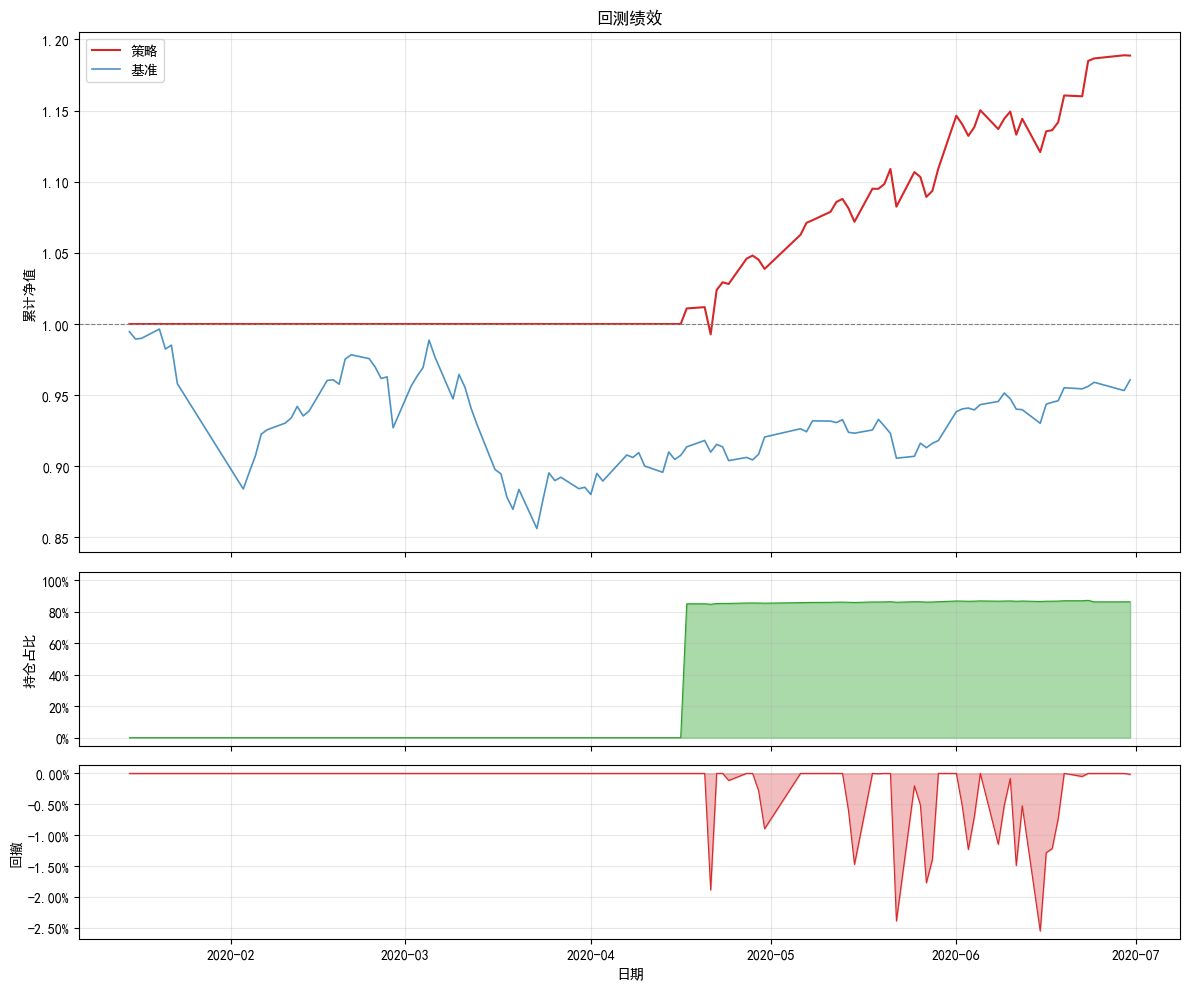

指标,值
总收益率,18.87%
年化收益率,49.68%
CAGR,49.68%
年化波动率,13.34%
最大回撤,-2.56%
夏普比率,3.0923
索提诺比率,5.9088
卡尔玛比率,19.4351
Omega,2.2383
Alpha,0.5226


Loading ITables v2.7.0 from the internet... (need help?)


Loading ITables v2.7.0 from the internet... (need help?)


In [7]:
ctx = run_backtest(
    initialize, None,
    start_date="2020-01-15", end_date="2020-06-30",
    capital=1000000, data_path="../data",
    benchmark="000001.SH", asset_type="stock", plot=True,
)
